In [26]:
#nieuwste versie 2.0
import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import time


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        # vaste basisneiging tot recyclen (normaal verdeeld)
        self.basis_recyclewaarde = min(1, max(0, random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Huishoudgrootte obvverdeling Nederland 2025
        self.huishoudgrootte = random.choices([1, 2, 3, 4, 5], weights=[55, 26, 9, 7, 3])[0]

        # Basis textielafval: 0,23 kg per persoon per week
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        # Basis textielafval 12 kg/persoon/jaar
        self.textielafval_per_week = 0.23 * 2.10  # kg/huishouden/week
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        self.weggooifrequentie = max(1, round(random.normalvariate(20, 4))) # in weken
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie hoeveelheid textielafval obv inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2

        # Correctie hoeveelheid textielafval obv geslacht
        if self.geslacht == "man":
            self.textielafval_per_tijdstap *= 0.9
        elif self.geslacht == "vrouw":
            self.textielafval_per_tijdstap *= 1.1


# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.capaciteit = 1250          # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0
        self.ledigingsfrequentie = 8    # 1 keer per 8 weken
        self.week = 0

    def ledigen(self):
        self.vulgraad = 0


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=90, people_per_container=10):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # check of alles op het grid past
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # alle gehele coördinaten op het grid
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        random.shuffle(beschikbare_posities)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # eerste berekening
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # Manhattan-afstand op het grid
    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buurinvloed berekenen:
    # +0.1 voor buur die recycelt
    # -0.1 voor buur die niet recycelt
    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.1
                        else:
                            buurinvloed -= 0.1

        return aantal_buren, buurinvloed

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # basis startwaarde recycle gedrag
            huishouden.recyclewaarde = huishouden.basis_recyclewaarde

            # buurinvloed
            aantal_buren, buurinvloed = self.bereken_buurinvloed(huishouden)
            huishouden.sociale_gevoeligheid = aantal_buren

            # afstand tot dichtstbijzijnde container
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # als huishouden direct naast een container woont -> altijd recyclen
            if afstand == 1:
                huishouden.recyclewaarde = self.drempel + 1
                huishouden.recyclegedrag = True
                continue

            # invloed buren
            huishouden.recyclewaarde += buurinvloed

            # invloed afstand
            huishouden.recyclewaarde -= afstand * 0.025

            # invloed inkomen
            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            # invloed geslacht
            if huishouden.geslacht == "vrouw":
                huishouden.recyclewaarde += 0.05
            elif huishouden.geslacht == "man":
                huishouden.recyclewaarde -= 0.05

            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # simulatiestap
    def stap(self):
        self.week += 4

        # huishoudens produceren textielafval
        for huishouden in self.huishoudens:
            huishouden.opgespaard_textielafval += huishouden.textielafval_per_tijdstap
            huishouden.weken_tot_weggooien -= 4

        # recyclegedrag opnieuw berekenen
        self.bereken_recyclegedrag()

        # textiel weggooien
        for huishouden in self.huishoudens:
            if huishouden.weken_tot_weggooien <= 0:
                if huishouden.recyclegedrag:
                    container, afstand = self.dichtstbijzijnde_container(huishouden)

                    if container.vulgraad + huishouden.opgespaard_textielafval <= container.capaciteit:
                        container.vulgraad += huishouden.opgespaard_textielafval
                    else:
                        container.vulgraad = container.capaciteit

                huishouden.opgespaard_textielafval = 0
                huishouden.weken_tot_weggooien = huishouden.weggooifrequentie

        # containers legen elke 8 weken
        if self.week % 26 == 0:
            for container in self.containers:
                container.ledigen()

    # resultaten weergeven
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Geslacht':<10} {'Afstand':<10} {'Opgespaard':<12} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )


# simulatie
for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()
    model.resultaten()

model = Stad()

fig, ax = plt.subplots(figsize=(7,7))

model model = Stad(width=10, height=10, num_people=90, people_per_container=10) # simulatie for week in range(4): print(f"\nWEEK {week + 1}") model.stap() model.visualiseer() model.resultaten() model = Stad() fig, ax = plt.subplots(figsize=(7,7)) # startbeeld model.visualiseer(ax) def update(frame): model.stap() model.visualiseer(ax) anim = FuncAnimation( fig, update, frames=20, interval=1000, repeat=False, cache_frame_data=False ) # 👉 werkt in notebook from IPython.display import HTML HTML(anim.to_jshtml())



WEEK 1


AttributeError: 'Stad' object has no attribute 'visualiseer'


WEEK 1


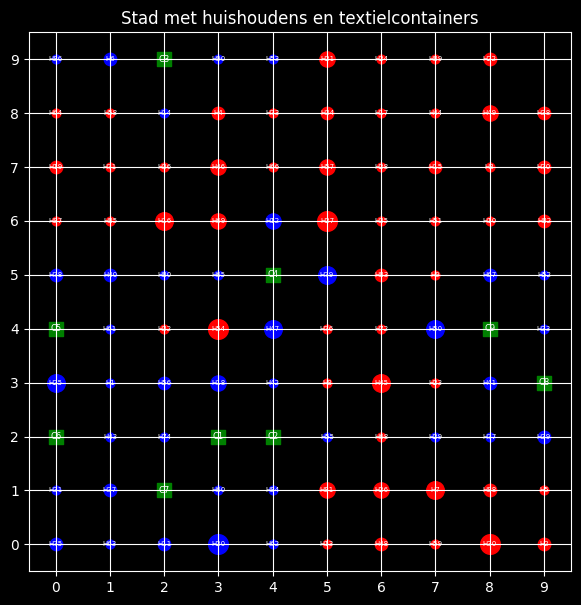


WEEK 2


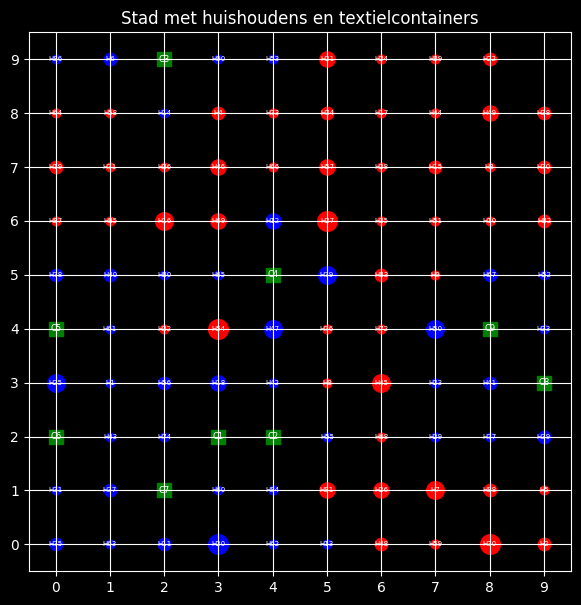


WEEK 3


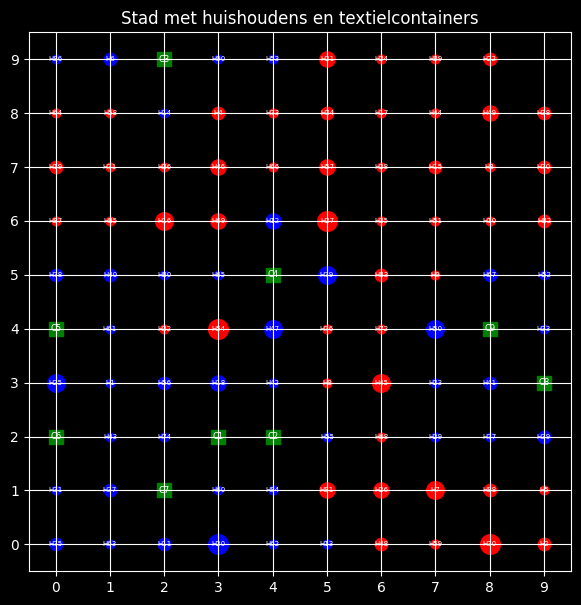


WEEK 4


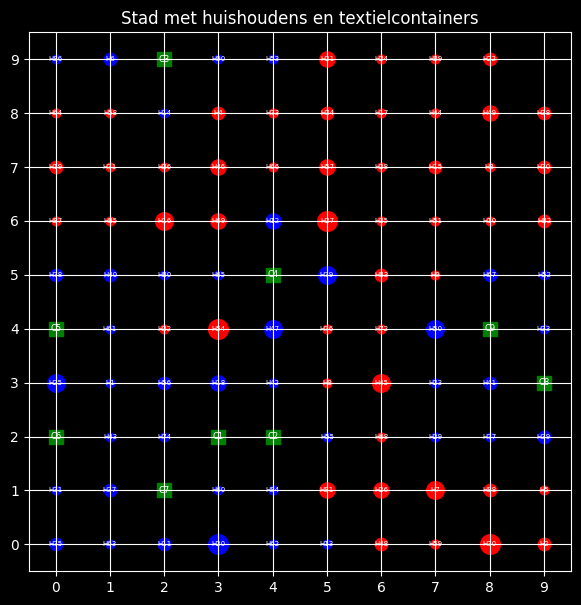

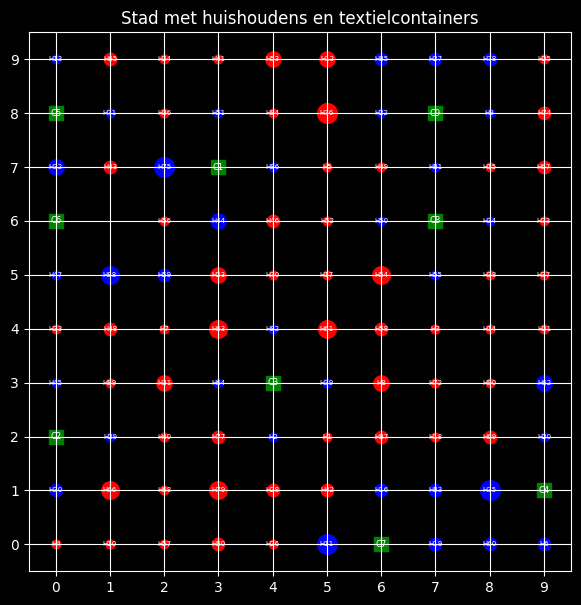

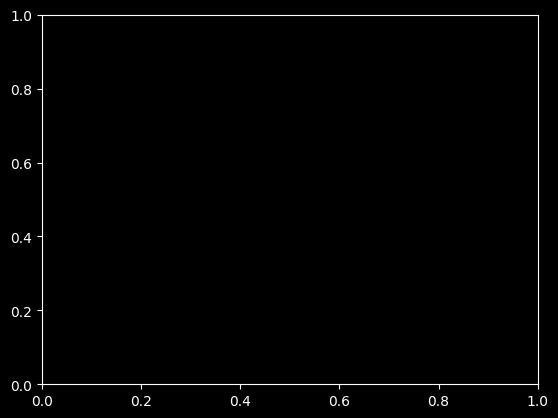

In [27]:
#nieuwste versie 2.0
import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import time


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        # vaste basisneiging tot recyclen (normaal verdeeld)
        self.basis_recyclewaarde = min(1, max(0, random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Huishoudgrootte obvverdeling Nederland 2025
        self.huishoudgrootte = random.choices([1, 2, 3, 4, 5], weights=[55, 26, 9, 7, 3])[0]

        # Basis textielafval: 0,23 kg per persoon per week
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        # Basis textielafval 12 kg/persoon/jaar
        self.textielafval_per_week = 0.23 * 2.10  # kg/huishouden/week
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        self.weggooifrequentie = max(1, round(random.normalvariate(20, 4))) # in weken
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie hoeveelheid textielafval obv inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2

        # Correctie hoeveelheid textielafval obv geslacht
        if self.geslacht == "man":
            self.textielafval_per_tijdstap *= 0.9
        elif self.geslacht == "vrouw":
            self.textielafval_per_tijdstap *= 1.1


# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.capaciteit = 1250          # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0
        self.ledigingsfrequentie = 8    # 1 keer per 8 weken
        self.week = 0

    def ledigen(self):
        self.vulgraad = 0


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=90, people_per_container=10):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # check of alles op het grid past
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # alle gehele coördinaten op het grid
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        random.shuffle(beschikbare_posities)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # eerste berekening
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [(x - 1, y),(x + 1, y),(x, y - 1),(x, y + 1)]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])
                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        buurinvloed += 0.1 if agent.recyclegedrag else -0.1

        return aantal_buren, buurinvloed

    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            huishouden.recyclewaarde = huishouden.basis_recyclewaarde
            aantal_buren, buurinvloed = self.bereken_buurinvloed(huishouden)
            huishouden.sociale_gevoeligheid = aantal_buren
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            if afstand == 1:
                huishouden.recyclegedrag = True
                continue

            huishouden.recyclewaarde += buurinvloed
            huishouden.recyclewaarde -= afstand * 0.025

            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            if huishouden.geslacht == "vrouw":
                huishouden.recyclewaarde += 0.05
            elif huishouden.geslacht == "man":
                huishouden.recyclewaarde -= 0.05

            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    def stap(self):
        self.week += 4

        for huishouden in self.huishoudens:
            huishouden.opgespaard_textielafval += huishouden.textielafval_per_tijdstap
            huishouden.weken_tot_weggooien -= 4

        self.bereken_recyclegedrag()

        for huishouden in self.huishoudens:
            if huishouden.weken_tot_weggooien <= 0:
                if huishouden.recyclegedrag:
                    container, _ = self.dichtstbijzijnde_container(huishouden)
                    container.vulgraad = min(container.capaciteit,
                                              container.vulgraad + huishouden.opgespaard_textielafval)
                huishouden.opgespaard_textielafval = 0
                huishouden.weken_tot_weggooien = huishouden.weggooifrequentie

        if self.week % 26 == 0:
            for container in self.containers:
                container.ledigen()

    # ✅ AANGEPAST: visualisatie werkt nu met en zonder ax
    def visualiseer(self, ax=None):
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=100, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        ax.grid()
        ax.set_title("Stad met huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))

        if ax is plt.gca():
            plt.show()


# model
model = Stad(width=10, height=10, num_people=90, people_per_container=10)

for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()

model = Stad()

fig, ax = plt.subplots(figsize=(7,7))
model.visualiseer(ax)

def update(frame):
    model.stap()
    model.visualiseer(ax)

anim = FuncAnimation(fig, update, frames=20, interval=1000, repeat=False)
HTML(anim.to_jshtml())

SAMENVATTING
----------------------------------------
Totaal geproduceerd textiel: 2942.16 kg
Totaal gerecycled textiel:   1475.68 kg
Totaal percentage gerecycled: 50.16%

RESULTATEN:

Huishouden   Grootte  Positie      Buren  Inkomen    Geslacht   Afstand    Opgespaard   Recyclewaarde    Status            
----------------------------------------------------------------------------------------------------------------------------------
H1           3        (8, 6)       4      midden     vrouw      3.00       6.07         0.42             recycleert_niet   
H2           1        (6, 9)       3      hoog       vrouw      5.00       0.00         0.26             recycleert_niet   
H3           2        (1, 1)       4      hoog       vrouw      2.00       0.00         1.00             recycleert        
H4           2        (7, 5)       4      laag       man        3.00       0.00         0.06             recycleert_niet   
H5           1        (5, 4)       4      laag       vrouw      

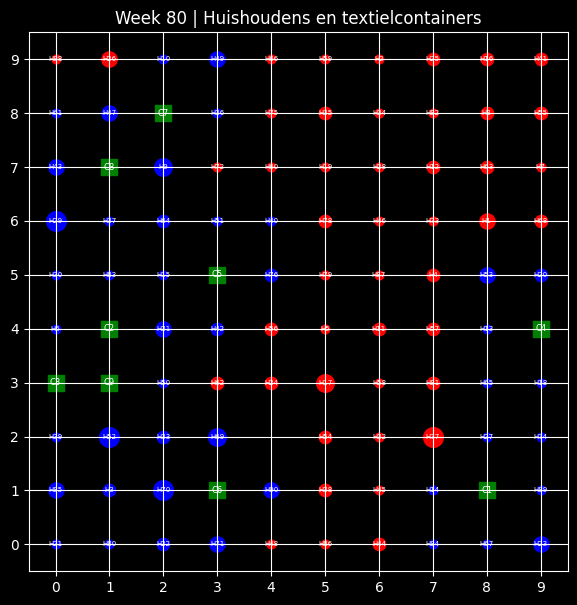

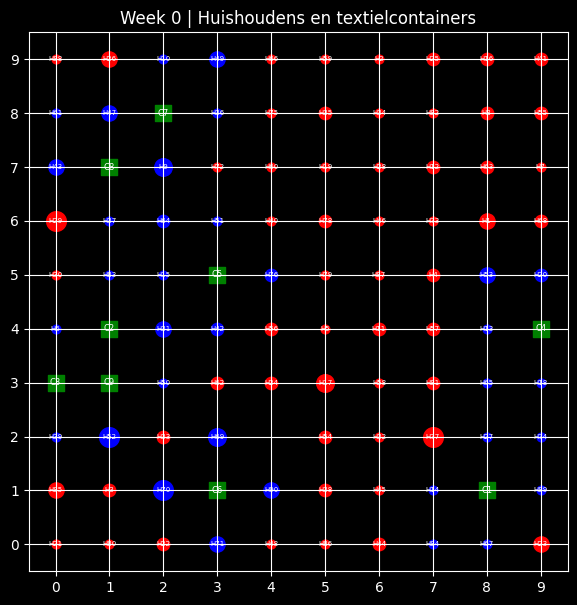

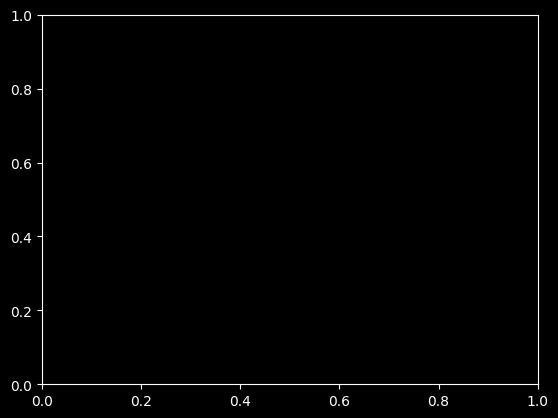

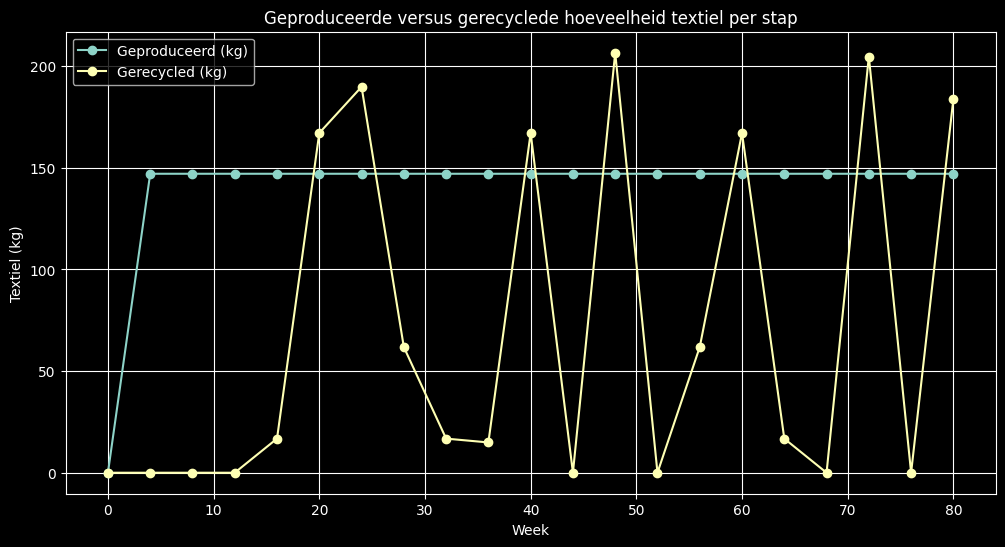

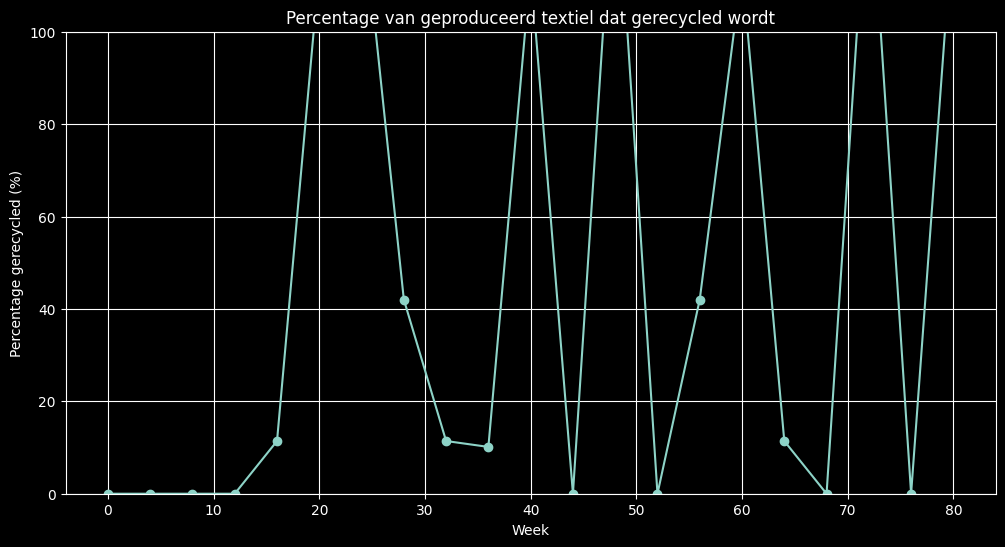

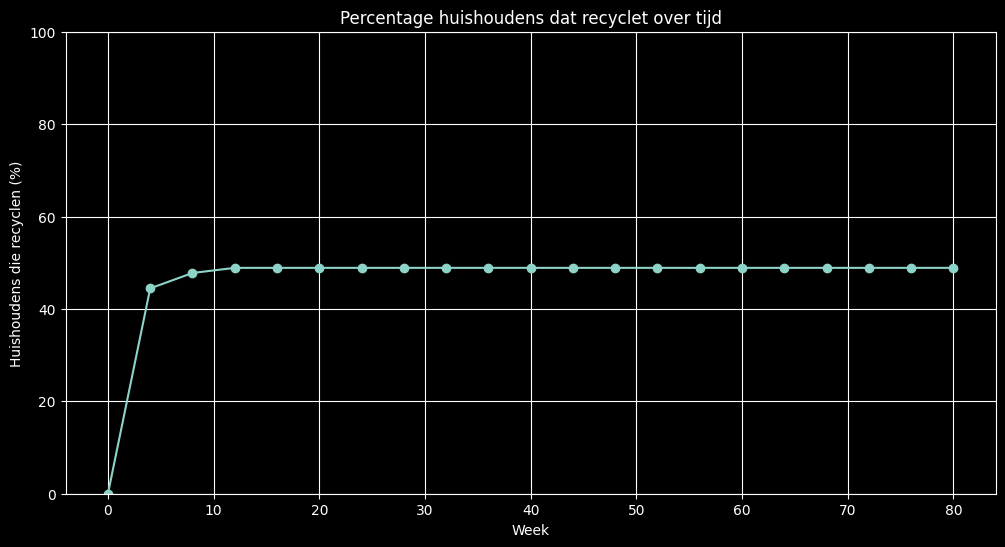

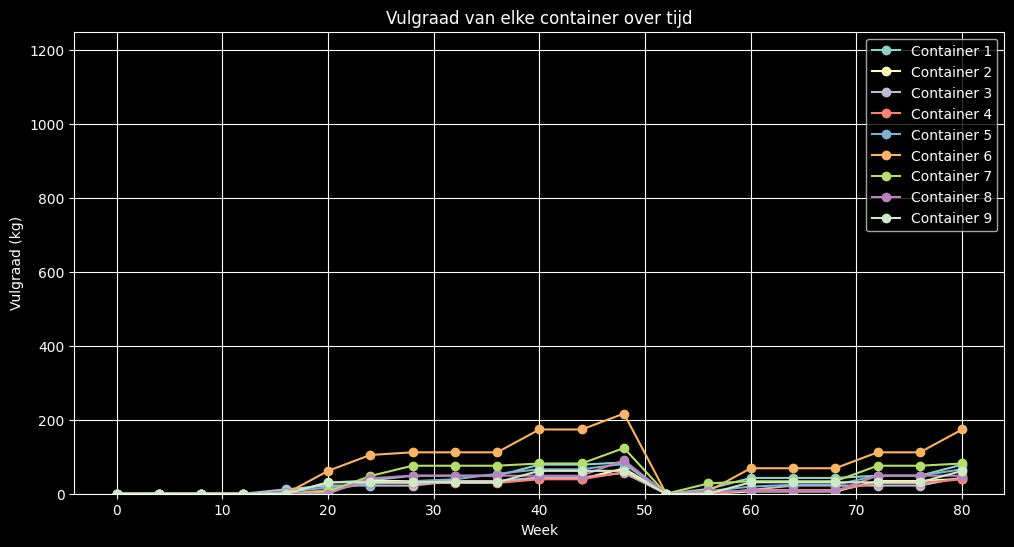

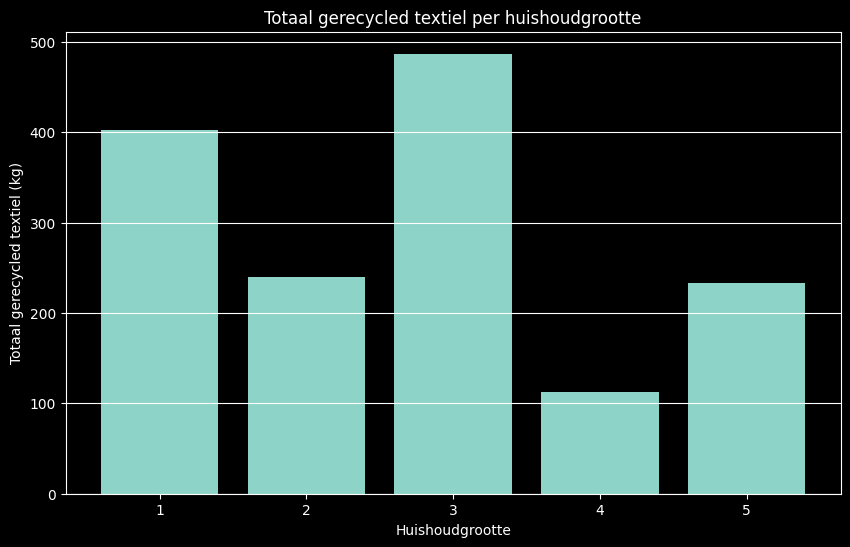

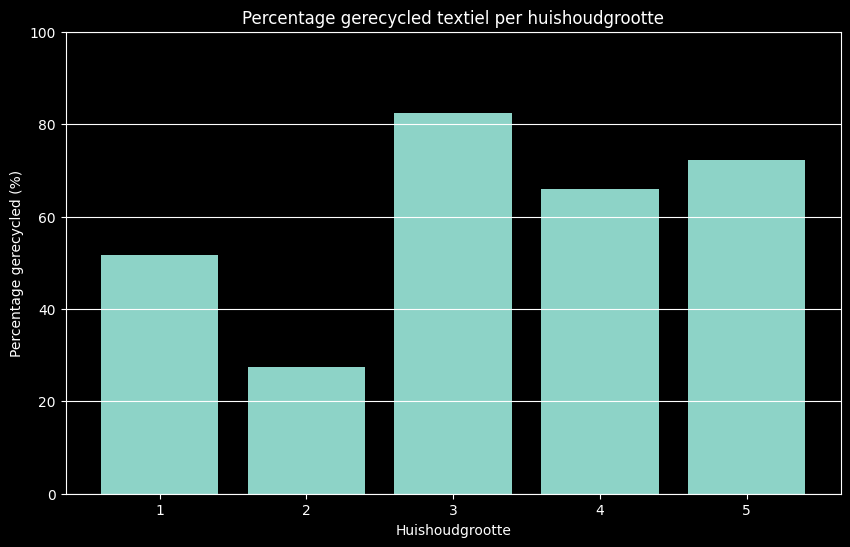

In [28]:
import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die:
    - een bepaalde huishoudgrootte heeft
    - textielafval opbouwt
    - beïnvloed wordt door buren
    - beslist of het recyclet op basis van een recyclewaarde
    - textiel wegbrengt naar de dichtstbijzijnde container
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Basisneiging om te recyclen.
        # Deze waarde ligt tussen 0 en 1 en is de start van het gedrag.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # Boolean: recyclet het huishouden op dit moment wel of niet?
        self.recyclegedrag = False

        # Extra status als tekst, zodat het model makkelijker uitlegbaar is.
        self.status = "recycleert_niet"

        # Sociaaldemografische kenmerken.
        self.opleidingsniveau = self.model.random.choice(["laag", "midden", "hoog"])
        self.inkomen = self.model.random.choice(["laag", "midden", "hoog"])
        self.geslacht = self.model.random.choice(["man", "vrouw"])

        # Huishoudgrootte zoals jij die nu al gebruikte.
        # Deze verdeling blijft dus behouden.
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 stap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 4)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval op basis van inkomen.
        # Dit verandert niet het gedrag, maar de hoeveelheid afval.
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2

        # Correctie op hoeveelheid textielafval op basis van geslacht.
        if self.geslacht == "man":
            self.textielafval_per_tijdstap *= 0.9
        elif self.geslacht == "vrouw":
            self.textielafval_per_tijdstap *= 1.1

        # Afstand tot dichtstbijzijnde container.
        # Deze wordt tijdens de simulatie berekend.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal geproduceerd heeft.
        self.totaal_geproduceerd = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):
        """
        Berekent de recyclewaarde opnieuw op basis van:
        - basisneiging
        - buurinvloed
        - afstand tot container
        - inkomen
        - geslacht

        Daarna wordt bepaald of het huishouden recyclet of niet.
        """
        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Als een huishouden direct naast een container woont,
        # dan laten we het altijd recyclen.
        if afstand == 1:
            self.recyclewaarde = 1
            self.recyclegedrag = True
            self.status = "recycleert"
            return

        # Invloed van buren.
        self.recyclewaarde += buurinvloed

        # Invloed van afstand.
        # Hoe groter de afstand, hoe lager de recyclewaarde.
        self.recyclewaarde -= afstand * 0.025

        # Invloed van inkomen.
        if self.inkomen == "hoog":
            self.recyclewaarde += 0.1
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.1

        # Invloed van geslacht.
        if self.geslacht == "vrouw":
            self.recyclewaarde += 0.05
        elif self.geslacht == "man":
            self.recyclewaarde -= 0.05

        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempelwaarde:
        # vanaf 0.5 recyclet het huishouden.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel

        # Tekststatus voor interpretatie en visualisatie.
        if self.recyclegedrag:
            self.status = "recycleert"
        else:
            self.status = "recycleert_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_geproduceerd += self.textielafval_per_tijdstap
        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
        Als het huishouden aan de beurt is om textiel weg te brengen:
        - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
        - anders verdwijnt het uit het systeem als 'niet gerecycled'

        Daarna wordt het opgespaard textiel gereset en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                # Beschikbare ruimte in de container.
                ruimte_over = container.capaciteit - container.vulgraad

                # Hoeveel effectief in de container past.
                hoeveelheid_te_recyclen = min(ruimte_over, self.opgespaard_textielafval)

                # Voeg de effectieve hoeveelheid toe aan de container.
                container.vulgraad += hoeveelheid_te_recyclen

                # Houd ook modeluitkomsten bij.
                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen

                # Houd bij hoeveel gerecycled wordt per huishoudgrootte.
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.geproduceerd_per_huishoudgrootte[self.huishoudgrootte] += self.opgespaard_textielafval
            else:
                # Ook als een huishouden niet recyclet, telt het geproduceerde textiel wel mee.
                self.model.geproduceerd_per_huishoudgrootte[self.huishoudgrootte] += self.opgespaard_textielafval

            # Na wegbrengen of weggooien wordt de opslag leeggemaakt.
            self.opgespaard_textielafval = 0

            # De teller wordt opnieuw ingesteld.
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg.
        self.capaciteit = 1250

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

        # Iedere 26 weken wordt de container geleegd.
        self.ledigingsfrequentie = 26

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

    def __init__(self, width=10, height=10, num_people=90, people_per_container=10, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Variabelen die per stap opnieuw worden gevuld.
        self.geproduceerd_deze_stap = 0
        self.gerecycled_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.percentage_gerecycled_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.geproduceerd_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

        # Aantal containers op basis van people_per_container.
        num_containers = math.ceil(num_people / people_per_container)

        # Check of alles in het grid past.
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # Maak alle coördinaten beschikbaar en schud ze door elkaar.
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        self.random.shuffle(beschikbare_posities)

        # Plaats containers.
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # Plaats huishoudens.
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.1
                        else:
                            buurinvloed -= 0.1

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)

        # Percentage gerecycled in deze stap.
        if self.geproduceerd_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.geproduceerd_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def step(self):
        """
        Eén modelstap:
        1. tijd vooruit zetten met 4 weken
        2. stap van elk huishouden uitvoeren
        3. containers legen indien nodig
        4. resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.geproduceerd_deze_stap = 0
        self.gerecycled_deze_stap = 0

        # Laat elk huishouden zijn eigen gedrag uitvoeren.
        for huishouden in self.huishoudens:
            huishouden.step()

        # Ledig alle containers elke 26 weken.
        if self.week % 26 == 0:
            for container in self.containers:
                container.ledigen()

        # Verzamel resultaten voor grafieken.
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10} {'Geslacht':<10} {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_geproduceerd_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel geproduceerd en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde versus gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het geproduceerde textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van geproduceerd textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i+1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 1250)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het geproduceerde textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            geproduceerd = self.geproduceerd_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if geproduceerd > 0:
                percentages.append((gerecycled / geproduceerd) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()


# ============================================================
# MODEL DRAAIEN
# ============================================================

# Maak één model aan.
model = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(20):
    model.step()

# Print enkele samenvattende resultaten.
totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_geproduceerd > 0:
    totaal_percentage = (totaal_gerecycled / totaal_geproduceerd) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Totaal percentage gerecycled: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)

def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)

anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_geproduceerd_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
